In [1]:
#🌡️ Extreme Temperatures 
#Paris → 75
#Lyon → 69
#Bordeaux → 33
#Marseille → 13

#We deliberately use daily data rather than hourly data because daily extremes are the standard basis 
#for climate and public-health heat indicators, while hourly data would substantially increase 
#complexity without improving robustness or interpretability for this project. Daily temperature profiles 
#could be used once heatwaves are IDed.  

#Note:
#Raw data files are not tracked in Git.
#Paths assume data is stored locally in ../data/.


In [2]:
#Import libraries

In [3]:
#math libraries
import pandas as pd

#plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#Functions

In [5]:
# define path for raw data
def load_city_data(path):
    """
    Load a Meteo-France CSV file and parse the date column.
    """
    df = pd.read_csv(path, sep=";")
    df["date"] = pd.to_datetime(df["AAAAMMJJ"], format="%Y%m%d")
    return df


# Select the top 5 meteo stations per city
def select_top_stations(df, min_tx_days=8000, min_end_year=2015, n_stations=5):
    """
    Select the best weather stations based on:
    - number of available TX (daily max temperature) values
    - recent data availability
    """
    summary = (
        df.groupby(["NUM_POSTE", "NOM_USUEL"])
          .agg(
              n_TX=("TX", "count"),
              start_date=("date", "min"),
              end_date=("date", "max")
          )
          .reset_index()
    )

    selected = (
        summary[
            (summary["n_TX"] >= min_tx_days) &
            (summary["end_date"].dt.year >= min_end_year)
        ]
        .sort_values("n_TX", ascending=False)
        .head(n_stations)
    )

    return selected


# Filter results by city/stations
def filter_city_by_stations(df, stations_df):
    """
    Keep only observations from the selected stations.
    """
    station_ids = stations_df["NUM_POSTE"].tolist()
    return df[df["NUM_POSTE"].isin(station_ids)].copy()


Load the data
| Variable | Description |
|--------|------------|
| NUM_POSTE | Station ID |
| NOM_USUEL | Station name |
| LAT | Latitude |
| LON | Longitude |
| ALTI | Altitude (m) |
| AAAAMMJJ | Date (YYYYMMDD) |
| date | Parsed date |
| RR | Daily precipitation (mm) |
| QRR | Quality flag (RR) |
| TN | Daily minimum temperature (°C) |
| QTN | Quality flag (TN) |
| HTN | Time of TN |
| TX | Daily maximum temperature (°C) |
| QTX | Quality flag (TX) |
| HTX | Time of TX |
| TM | Mean daily temperature (°C) |
| QTM | Quality flag (TM) |
| TNTXM | (TN + TX) / 2 |
| TAMPLI | Daily thermal amplitude (TX − TN) |
| TNSOL | Min ground temperature (10 cm) |
| TN50 | Min temperature at 50 cm |
| DG | Frost duration (minutes) |
| FFM | Mean daily wind speed (10 m) |
| FF2M | Mean wind speed (2 m) |
| FXY | Max hourly wind (10 m) |
| DXY | Direction of max wind |
| HXY | Time of max wind |
| FXI | Max instantaneous wind (10 m) |
| DXI | Direction of FXI |
| HXI | Time of FXI |
| FXI2 | Max instantaneous wind (2 m) |
| FXI3S | Max 3-second wind gust |
| DRR | Duration of precipitation (min) |
| Q* | Quality flag for variable `*` |


In [6]:
# =========================
# Base path to data folder
# =========================
DATA_DIR = "/home/simcard/projects/extreme_heat/data"

# =========================
# File paths
# =========================
PATH_75 = f"{DATA_DIR}/Paris_Q_75_previous-1950-2023_RR-T-Vent.csv"
PATH_13 = f"{DATA_DIR}/Marseille_Q_13_previous-1950-2023_RR-T-Vent.csv"
PATH_33 = f"{DATA_DIR}/Bordeaux_Q_33_previous-1950-2023_RR-T-Vent.csv"
PATH_69 = f"{DATA_DIR}/Lyon_Q_69_previous-1950-2023_RR-T-Vent.csv"

# =========================
# Load data
# =========================
df_75 = load_city_data(PATH_75)
df_13 = load_city_data(PATH_13)
df_33 = load_city_data(PATH_33)
df_69 = load_city_data(PATH_69)


# =========================
# Preview data
# =========================
print('Paris')
display(df_75.head())
display(df_75.columns)
print('Marseille')
display(df_13.head())
display(df_13.columns)
print('Bordeaux')
display(df_33.head())
display(df_33.columns)
print('Lyon')
display(df_69.head())
display(df_69.columns)

Paris


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,date
0,75101001,INNOCENTS,48.860667,2.348333,37,19500101,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950-01-01
1,75101001,INNOCENTS,48.860667,2.348333,37,19500102,1.8,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950-01-02
2,75101001,INNOCENTS,48.860667,2.348333,37,19500103,2.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950-01-03
3,75101001,INNOCENTS,48.860667,2.348333,37,19500104,0.2,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950-01-04
4,75101001,INNOCENTS,48.860667,2.348333,37,19500105,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950-01-05


Index(['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'QRR',
       'TN', 'QTN', 'HTN', 'QHTN', 'TX', 'QTX', 'HTX', 'QHTX', 'TM', 'QTM',
       'TNTXM', 'QTNTXM', 'TAMPLI', 'QTAMPLI', 'TNSOL', 'QTNSOL', 'TN50',
       'QTN50', 'DG', 'QDG', 'FFM', 'QFFM', 'FF2M', 'QFF2M', 'FXY', 'QFXY',
       'DXY', 'QDXY', 'HXY', 'QHXY', 'FXI', 'QFXI', 'DXI', 'QDXI', 'HXI',
       'QHXI', 'FXI2', 'QFXI2', 'DXI2', 'QDXI2', 'HXI2', 'QHXI2', 'FXI3S',
       'QFXI3S', 'DXI3S', 'QDXI3S', 'HXI3S', 'QHXI3S', 'DRR', 'QDRR', 'date'],
      dtype='object')

Marseille


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,date
0,13001002,AIX-PUYRICARD,43.593333,5.413333,314,19620701,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962-07-01
1,13001002,AIX-PUYRICARD,43.593333,5.413333,314,19620702,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962-07-02
2,13001002,AIX-PUYRICARD,43.593333,5.413333,314,19620703,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962-07-03
3,13001002,AIX-PUYRICARD,43.593333,5.413333,314,19620704,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962-07-04
4,13001002,AIX-PUYRICARD,43.593333,5.413333,314,19620705,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962-07-05


...

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,date
0,33004001,AMBES,45.041667,-0.608333,5,19571215,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1957-12-15
1,33004001,AMBES,45.041667,-0.608333,5,19571216,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1957-12-16
2,33004001,AMBES,45.041667,-0.608333,5,19571217,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1957-12-17
3,33004001,AMBES,45.041667,-0.608333,5,19571218,21.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1957-12-18
4,33004001,AMBES,45.041667,-0.608333,5,19571219,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1957-12-19


Index(['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'QRR',
       'TN', 'QTN', 'HTN', 'QHTN', 'TX', 'QTX', 'HTX', 'QHTX', 'TM', 'QTM',
       'TNTXM', 'QTNTXM', 'TAMPLI', 'QTAMPLI', 'TNSOL', 'QTNSOL', 'TN50',
       'QTN50', 'DG', 'QDG', 'FFM', 'QFFM', 'FF2M', 'QFF2M', 'FXY', 'QFXY',
       'DXY', 'QDXY', 'HXY', 'QHXY', 'FXI', 'QFXI', 'DXI', 'QDXI', 'HXI',
       'QHXI', 'FXI2', 'QFXI2', 'DXI2', 'QDXI2', 'HXI2', 'QHXI2', 'FXI3S',
       'QFXI3S', 'DXI3S', 'QDXI3S', 'HXI3S', 'QHXI3S', 'DRR', 'QDRR', 'date'],
      dtype='object')

Lyon


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QHXI2,FXI3S,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,date
0,69006001,AMPLEPUIS BOURG,45.971667,4.331667,435,19630301,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963-03-01
1,69006001,AMPLEPUIS BOURG,45.971667,4.331667,435,19630302,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963-03-02
2,69006001,AMPLEPUIS BOURG,45.971667,4.331667,435,19630303,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963-03-03
3,69006001,AMPLEPUIS BOURG,45.971667,4.331667,435,19630304,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963-03-04
4,69006001,AMPLEPUIS BOURG,45.971667,4.331667,435,19630305,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963-03-05


Index(['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'QRR',
       'TN', 'QTN', 'HTN', 'QHTN', 'TX', 'QTX', 'HTX', 'QHTX', 'TM', 'QTM',
       'TNTXM', 'QTNTXM', 'TAMPLI', 'QTAMPLI', 'TNSOL', 'QTNSOL', 'TN50',
       'QTN50', 'DG', 'QDG', 'FFM', 'QFFM', 'FF2M', 'QFF2M', 'FXY', 'QFXY',
       'DXY', 'QDXY', 'HXY', 'QHXY', 'FXI', 'QFXI', 'DXI', 'QDXI', 'HXI',
       'QHXI', 'FXI2', 'QFXI2', 'DXI2', 'QDXI2', 'HXI2', 'QHXI2', 'FXI3S',
       'QFXI3S', 'DXI3S', 'QDXI3S', 'HXI3S', 'QHXI3S', 'DRR', 'QDRR', 'date'],
      dtype='object')

Select stations (same logic for all cities)

In [7]:
stations_75 = select_top_stations(df_75)
stations_13 = select_top_stations(df_13)
stations_33 = select_top_stations(df_33)
stations_69 = select_top_stations(df_69)

Keep the top 5 stations per city

In [8]:
df_75 = filter_city_by_stations(df_75, stations_75)
df_13 = filter_city_by_stations(df_13, stations_13)
df_33 = filter_city_by_stations(df_33, stations_33)
df_69 = filter_city_by_stations(df_69, stations_69)

Examine the stations selected

In [9]:
print("Paris stations:")
print(stations_75[["NUM_POSTE", "NOM_USUEL", "n_TX"]])
print('\n')
print("Lyon stations:")
print(stations_69[["NUM_POSTE", "NOM_USUEL", "n_TX"]])
print('\n')
print("Bordeaux stations:")
print(stations_33[["NUM_POSTE", "NOM_USUEL", "n_TX"]])
print('\n')
print("Marseille stations:")
print(stations_13[["NUM_POSTE", "NOM_USUEL", "n_TX"]])


Paris stations:
    NUM_POSTE         NOM_USUEL   n_TX
16   75114001  PARIS-MONTSOURIS  27028
3    75106001        LUXEMBOURG  16648
23   75116002         BAGATELLE   9608
15   75113002       SALPETRIERE   9556
6    75107005       TOUR EIFFEL   9220


Lyon stations:
    NUM_POSTE       NOM_USUEL   n_TX
10   69029001       LYON-BRON  27028
75   69204002  ST-GENIS-LAVAL  26962
56   69141001         MORNANT  26655
53   69135001         MONSOLS  26508
99   69264001    VILLEFRANCHE  24461


Bordeaux stations:
     NUM_POSTE                NOM_USUEL   n_TX
81    33281001        BORDEAUX-MERIGNAC  27028
75    33236002               CAP-FERRET  27028
143   33529001                   CAZAUX  27028
131   33504001                SAUTERNES  27027
153   33550001  VILLENAVE D'ORNON-INRAE  26997


Marseille stations:
     NUM_POSTE          NOM_USUEL   n_TX
44    13047001             ISTRES  27028
51    13054001          MARIGNANE  27028
108   13103001  SALON DE PROVENCE  27028
2     13001009    AIX 

👀 Visualize Tx (Max temp: weather) and averaged tempartures (climate change)

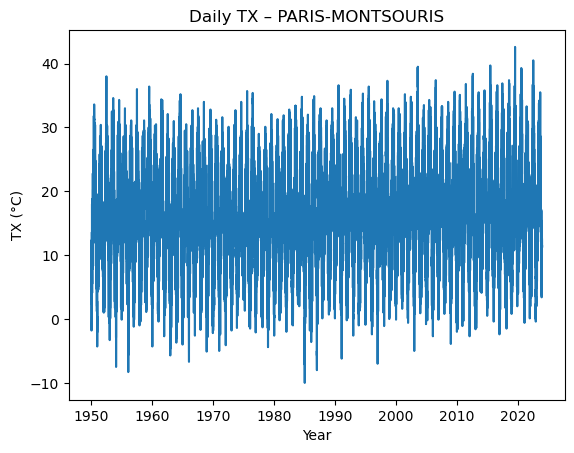

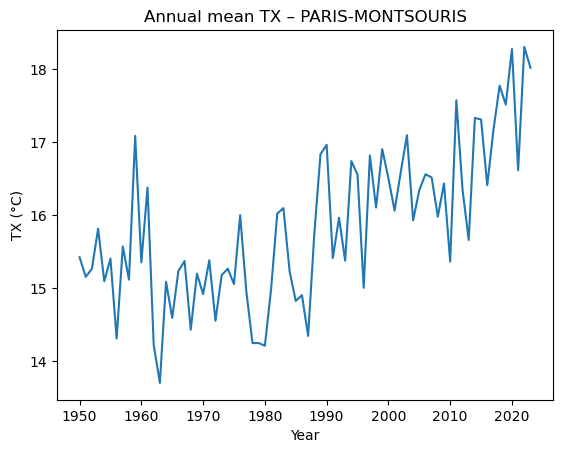

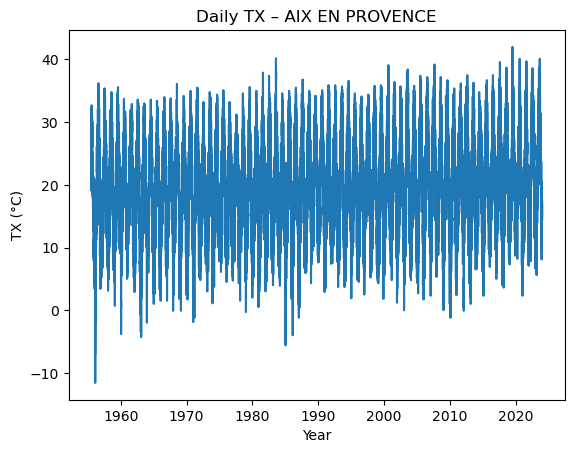

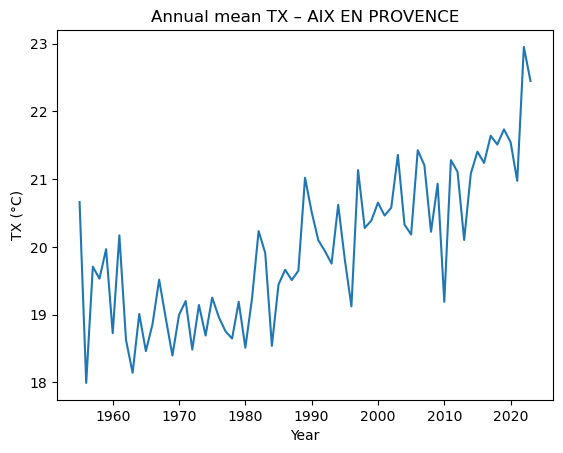

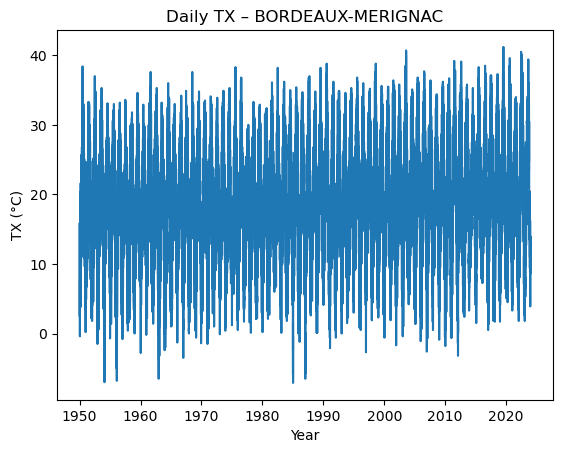

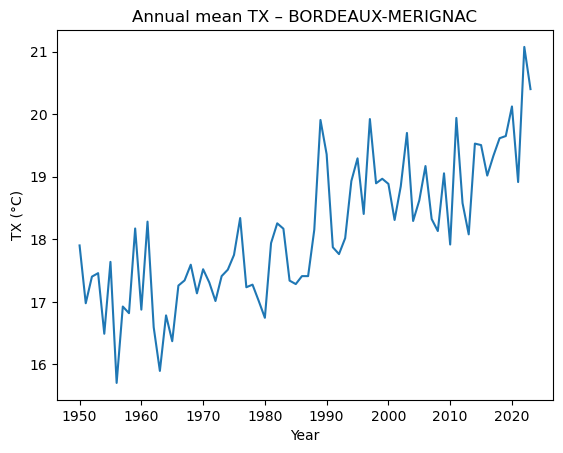

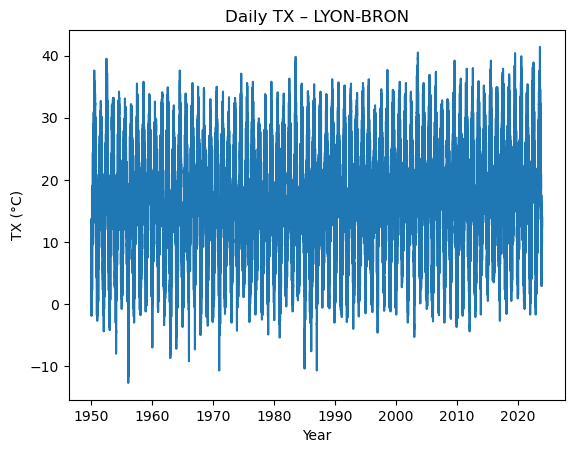

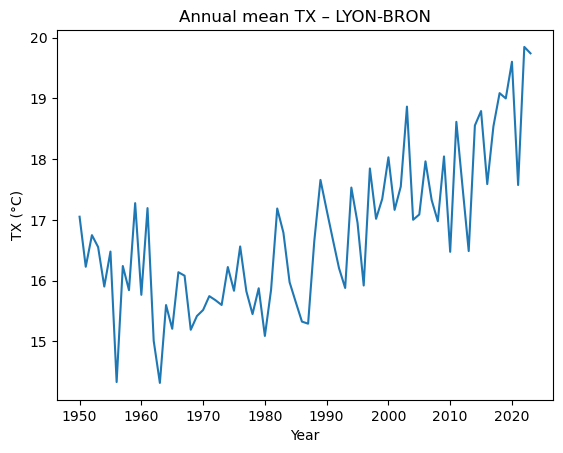

In [10]:


# =========================
# Functions 
# =========================

def prepare_df(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["AAAAMMJJ"], format="%Y%m%d")
    return df

def station_quality(df):
    return (
        df.groupby("NOM_USUEL")["TX"]
        .apply(lambda x: x.isna().mean())
        .sort_values()
    )

def plot_daily_tx(df, station):
    d = df[df["NOM_USUEL"] == station]
    plt.figure()
    plt.plot(d["date"], d["TX"])
    plt.title(f"Daily TX – {station}")
    plt.xlabel("Year")
    plt.ylabel("TX (°C)")
    plt.show()

# This operation groups daily TX values by calendar year and 
# computes the arithmetic mean for each year, without applying any running or rolling average.
def plot_annual_tx(df, station):
    d = df[df["NOM_USUEL"] == station].dropna(subset=["TX"])
    d["year"] = d["date"].dt.year
    annual = d.groupby("year")["TX"].mean()

    plt.figure()
    plt.plot(annual.index, annual.values)
    plt.title(f"Annual mean TX – {station}")
    plt.xlabel("Year")
    plt.ylabel("TX (°C)")
    plt.show()

def export_city(df, city_name):
    cols = ["date", "NUM_POSTE", "NOM_USUEL", "TX", "TN", "LAT", "LON", "ALTI"]
    df[cols].to_csv(f"{city_name}_daily_TX_raw.csv", index=False)

# =========================
# Apply to all cities
# =========================

cities = {
    "Paris": df_75,
    "Marseille": df_13,
    "Bordeaux": df_33,
    "Lyon": df_69
}

for city, df in cities.items():
    df = prepare_df(df)

    tx_missing = station_quality(df)
    best_station = tx_missing.index[0]

    plot_daily_tx(df, best_station)
    plot_annual_tx(df, best_station)

    export_city(df, city)

Paris – Best station: PARIS-MONTSOURIS


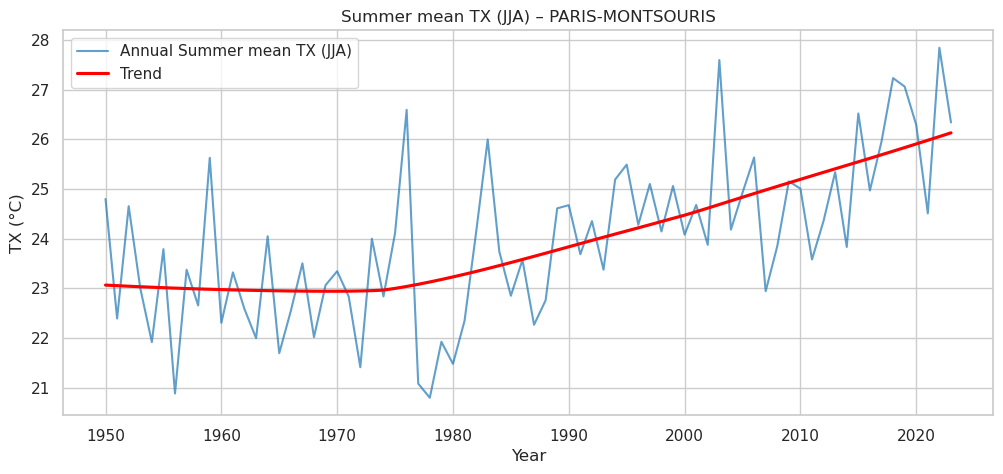

Marseille – Best station: AIX EN PROVENCE


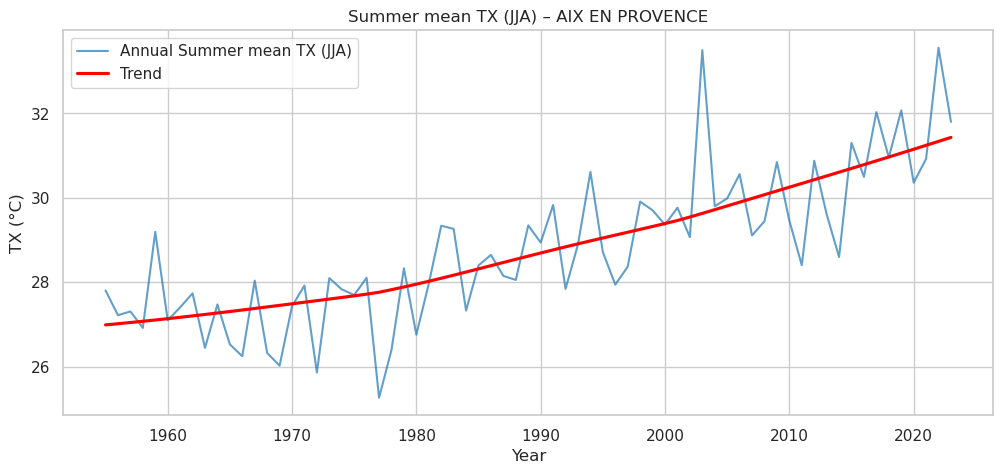

Bordeaux – Best station: BORDEAUX-MERIGNAC


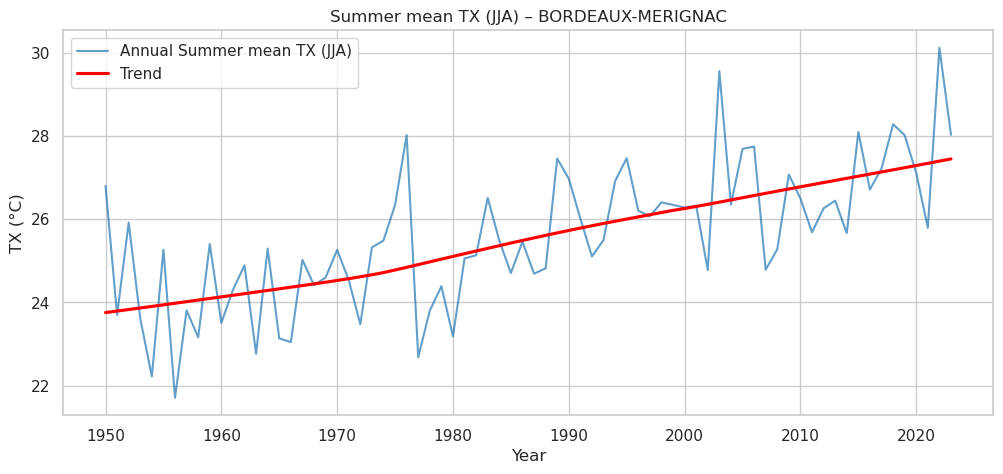

Lyon – Best station: LYON-BRON


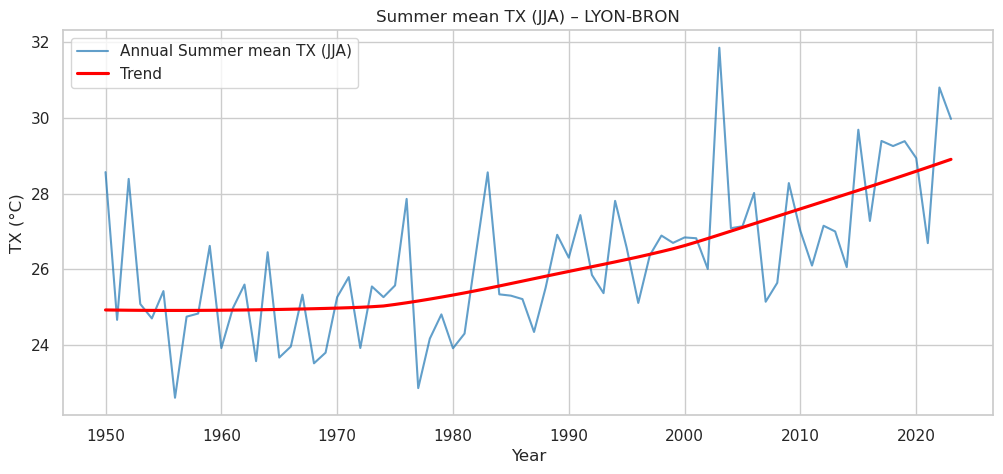

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (12, 5)

def plot_summer_mean_tx_trend(df, station):
    """
    Plots mean TX for summer months (JJA) for a given station with a smoothed trend line.
    """
    # Filter summer months
    summer_df = df[(df["NOM_USUEL"] == station) & (df["date"].dt.month.isin([6,7,8]))].dropna(subset=["TX"])
    
    # Compute annual summer mean
    summer_mean = summer_df.groupby(summer_df["date"].dt.year)["TX"].mean()
    
    # Plot
    plt.figure()
    sns.lineplot(x=summer_mean.index, y=summer_mean, alpha=0.7, label="Annual Summer mean TX (JJA)")
    
    # Add smoothed trend line
    sns.regplot(x=summer_mean.index, y=summer_mean.values, scatter=False, lowess=True, color="red", label="Trend")
    
    plt.title(f"Summer mean TX (JJA) – {station}")
    plt.xlabel("Year")
    plt.ylabel("TX (°C)")
    plt.legend()
    plt.show()


# =========================
# All cities
# =========================
cities = {
    "Paris": df_75,
    "Marseille": df_13,
    "Bordeaux": df_33,
    "Lyon": df_69
}

# Loop through cities
for city, df in cities.items():
    # Pick the best station (fewest missing TX)
    best_station = df.groupby("NOM_USUEL")["TX"].apply(lambda x: x.isna().mean()).sort_values().index[0]
    
    print(f"{city} – Best station: {best_station}")
    plot_summer_mean_tx_trend(df, best_station)


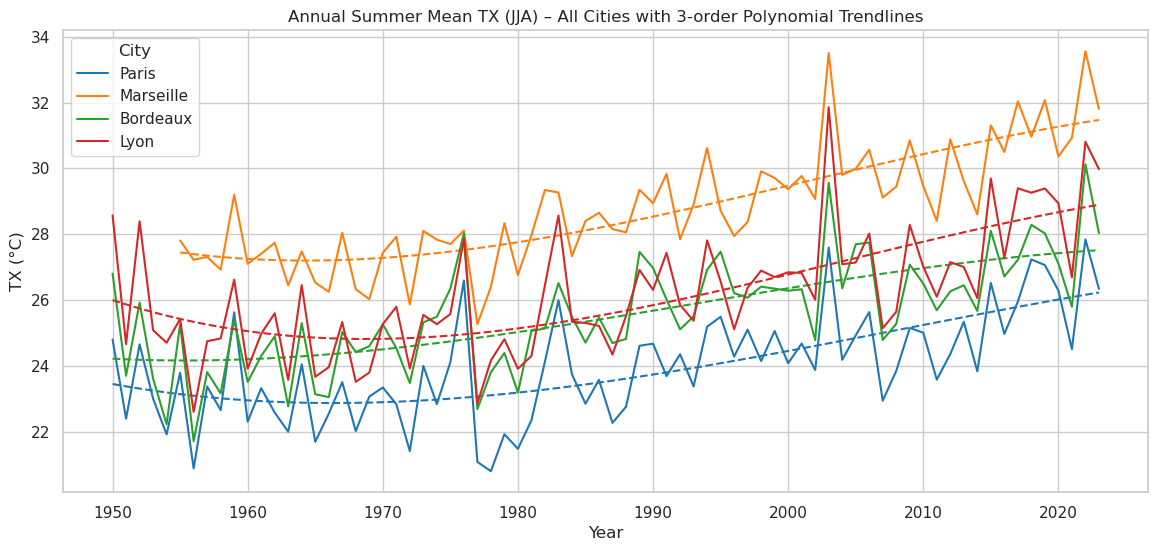

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (14, 6)

# =========================
# Function: plot all cities with polynomial trendlines
# =========================
def plot_summer_mean_tx_all_cities_poly(df_dict, poly_order=3):
    """
    Plots annual summer mean TX (JJA) for all cities with a dashed polynomial trend line for each city.
    - poly_order: order of the polynomial for trend line
    """
    fig, ax = plt.subplots(figsize=(14,6))
    
    for city, df in df_dict.items():
        # Select the best station
        best_station = df.groupby("NOM_USUEL")["TX"].apply(lambda x: x.isna().mean()).sort_values().index[0]
        
        # Filter summer months
        summer_df = df[(df["NOM_USUEL"] == best_station) & (df["date"].dt.month.isin([6,7,8]))].dropna(subset=["TX"])
        
        # Compute annual summer mean
        summer_mean = summer_df.groupby(summer_df["date"].dt.year)["TX"].mean()
        
        # Plot annual mean
        sns.lineplot(x=summer_mean.index, y=summer_mean, label=city, ax=ax)
        
        # Compute polynomial trend
        x = summer_mean.index.values
        y = summer_mean.values
        coeffs = np.polyfit(x, y, poly_order)
        trend = np.poly1d(coeffs)
        
        # Plot dashed polynomial trend line
        ax.plot(x, trend(x), linestyle='--', color=ax.get_lines()[-1].get_color())
    
    ax.set_title(f"Annual Summer Mean TX (JJA) – All Cities with {poly_order}-order Polynomial Trendlines")
    ax.set_xlabel("Year")
    ax.set_ylabel("TX (°C)")
    ax.legend(title="City")
    plt.show()


# =========================
# Dictionary of city DataFrames
# =========================
cities = {
    "Paris": df_75,
    "Marseille": df_13,
    "Bordeaux": df_33,
    "Lyon": df_69
}

# Plot with 3rd-order polynomial trendline
plot_summer_mean_tx_all_cities_poly(cities, poly_order=3)


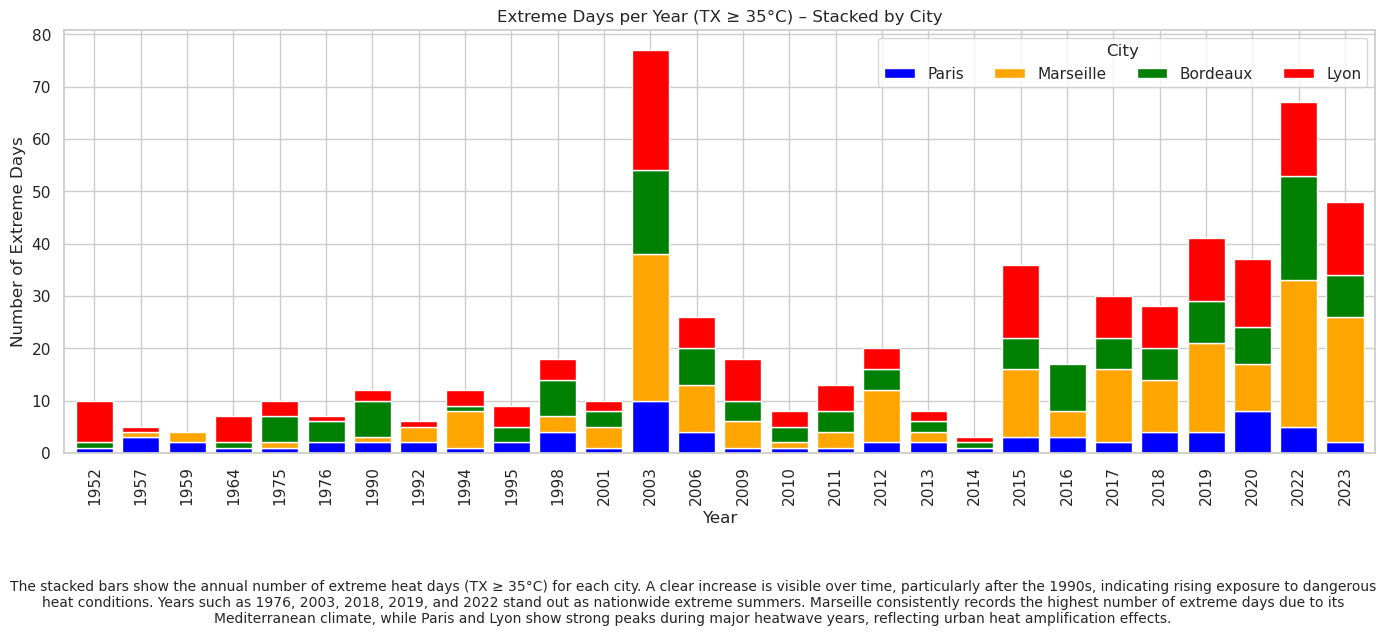

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

# =========================
# Dictionary with cities and DataFrames
# =========================
cities = {
    "Paris": df_75,
    "Marseille": df_13,
    "Bordeaux": df_33,
    "Lyon": df_69
}

# =========================
# Calculation: number of days per year with TX >= 35°C
# =========================
extreme_days_all = pd.DataFrame()

for city, df in cities.items():
    # Select the best station
    best_station = df.groupby("NOM_USUEL")["TX"].apply(lambda x: x.isna().mean()).sort_values().index[0]
    
    # Filter TX >= 35 (and optionally only summer months)
    extreme_df = df[(df["NOM_USUEL"] == best_station) & (df["TX"] >= 35)]
    
    # Count number of days per year
    extreme_count = extreme_df.groupby(extreme_df["date"].dt.year)["TX"].count()
    
    # Insert into DataFrame
    extreme_days_all[city] = extreme_count

# Replace NaN with 0 (years without extreme days)
extreme_days_all_filled = extreme_days_all.fillna(0)

# Ensure chronological order
extreme_days_all_filled.sort_index(inplace=True)

# =========================
# Colors for cities
# =========================
city_colors = {
    "Paris": "blue",
    "Marseille": "orange",
    "Bordeaux": "green",
    "Lyon": "red"
}

# =========================
# Stacked Bar Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 6))

extreme_days_all_filled.plot(
    kind="bar",
    stacked=True,
    color=[city_colors[c] for c in extreme_days_all_filled.columns],
    width=0.8,
    ax=ax
)

# Axis labels and title
ax.set_title("Extreme Days per Year (TX ≥ 35°C) – Stacked by City")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Extreme Days")
ax.legend(title="City", ncol=4)

# Interpretation below the figure
fig.text(
    0.5,
    0.02,
    "The stacked bars show the annual number of extreme heat days (TX ≥ 35°C) for each city. "
    "A clear increase is visible over time, particularly after the 1990s, indicating rising "
    "exposure to dangerous heat conditions. Years such as 1976, 2003, 2018, 2019, and 2022 "
    "stand out as nationwide extreme summers. Marseille consistently records the highest number "
    "of extreme days due to its Mediterranean climate, while Paris and Lyon show strong peaks "
    "during major heatwave years, reflecting urban heat amplification effects.",
    ha="center",
    va="top",
    fontsize=10,
    wrap=True
)

# Adjust layout to make space for the interpretation text
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


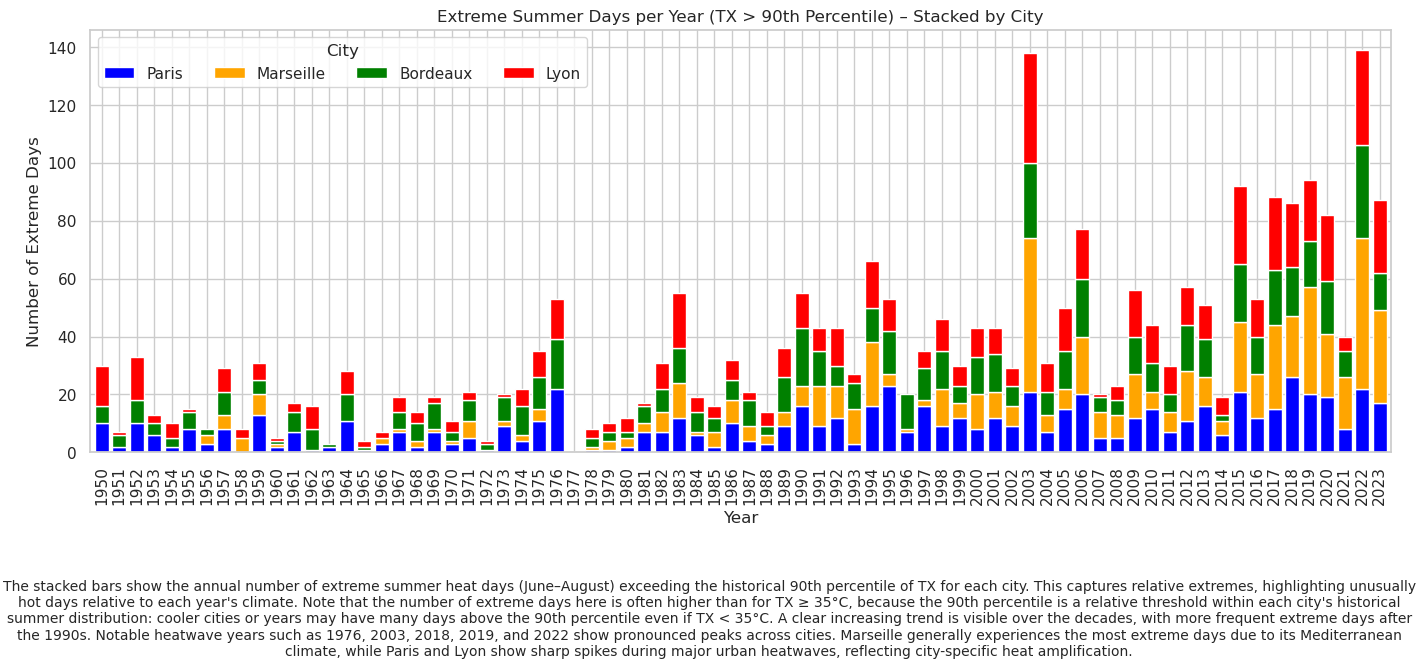

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

# =========================
# Dictionary with cities and DataFrames
# =========================
cities = {
    "Paris": df_75,
    "Marseille": df_13,
    "Bordeaux": df_33,
    "Lyon": df_69
}

# =========================
# Calculation: number of summer days (JJA) above historical 90th percentile
# =========================
extreme_days_90 = pd.DataFrame()

for city, df in cities.items():
    # Select the best station
    best_station = df.groupby("NOM_USUEL")["TX"].apply(lambda x: x.isna().mean()).sort_values().index[0]
    
    # Only summer months (JJA)
    df_city = df[(df["NOM_USUEL"] == best_station) & (df["date"].dt.month.isin([6,7,8]))].copy()
    
    # Historical 90th percentile (all summer months over all years)
    threshold = df_city["TX"].quantile(0.9)
    
    # Extract year
    df_city["year"] = df_city["date"].dt.year
    
    # Count number of days per year above 90th percentile
    extreme_per_year = df_city.groupby("year")["TX"].apply(lambda x: (x > threshold).sum())
    
    extreme_days_90[city] = extreme_per_year

# Fill missing years with 0
extreme_days_90 = extreme_days_90.fillna(0).sort_index()

# =========================
# Colors for cities
# =========================
city_colors = {
    "Paris": "blue",
    "Marseille": "orange",
    "Bordeaux": "green",
    "Lyon": "red"
}

# =========================
# Stacked Bar Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 6))

extreme_days_90.plot(
    kind="bar",
    stacked=True,
    color=[city_colors[c] for c in extreme_days_90.columns],
    width=0.8,
    ax=ax
)

ax.set_title("Extreme Summer Days per Year (TX > 90th Percentile) – Stacked by City")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Extreme Days")
ax.legend(title="City", ncol=4)

# =========================
# Interpretation below the figure
# =========================
fig.text(
    0.5,
    0.02,
    "The stacked bars show the annual number of extreme summer heat days (June–August) "
    "exceeding the historical 90th percentile of TX for each city. "
    "This captures relative extremes, highlighting unusually hot days relative to each year's climate. "
    "Note that the number of extreme days here is often higher than for TX ≥ 35°C, because the 90th percentile "
    "is a relative threshold within each city's historical summer distribution: cooler cities or years "
    "may have many days above the 90th percentile even if TX < 35°C. "
    "A clear increasing trend is visible over the decades, with more frequent extreme days after the 1990s. "
    "Notable heatwave years such as 1976, 2003, 2018, 2019, and 2022 show pronounced peaks across cities. "
    "Marseille generally experiences the most extreme days due to its Mediterranean climate, "
    "while Paris and Lyon show sharp spikes during major urban heatwaves, reflecting city-specific heat amplification.",
    ha="center",
    va="top",
    fontsize=10,
    wrap=True
)

# Adjust layout to make space for the interpretation text
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
